# Notebook 09 - Uncertainty Quantification (CLIMADA unsequa)

City-agnostic notebook for **Rome / Athens / Lisbon**.

Cf. Matrix for Uncertainty Quantification

Excluded on purpose: **the two hand-estimated IF families**. This
notebook uses only: 
- `burke_polynomial`
- `burke_powerlaw`

## What Is Quantified Here

-   Hazard: year, climate scenario, delta band, baseline mode,
    waste-heat parameters, tree-cooling parameters.
-   Exposure: year, SSP (for 2040/2050), total exposure scaling.
-   Impact functions: family (poly vs power-law), T_ref, MDD age scales,
    displacement, PAA.
-   AC + EWS policy effects represented as IF mortality modifiers
    (age-aware where available).

Notes: 
- Climate deltas use `climate_change_provide_markups_bands.csv`
when available; otherwise fallback to legacy avg table.
- ssp585 typically has `central` band only; low/high requests are auto-fallback
to central.
- EWS cost model is sampled for traceability but does not
change mortality impacts directly.

In [1]:
import os
from pathlib import Path

# City switch (edit only this for duplicated city copies if needed)
os.environ.setdefault("CITY", "rome")
SLUG = os.environ["CITY"].strip().lower()

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "cityheat").exists():
    ROOT = ROOT.parent
if not (ROOT / "cityheat").exists():
    ROOT = Path("/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat")

os.environ.setdefault("MPLCONFIGDIR", str(ROOT / "outputs" / ".mpl"))
os.environ.setdefault("XDG_CACHE_HOME", str(ROOT / "outputs" / ".cache"))
(ROOT / "outputs" / ".mpl").mkdir(parents=True, exist_ok=True)
(ROOT / "outputs" / ".cache").mkdir(parents=True, exist_ok=True)

assert (ROOT / "climada.conf").exists(), f"Missing climada.conf at {ROOT}"
print("ROOT:", ROOT)
print("SLUG:", SLUG)

ROOT: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat
SLUG: rome

In [2]:
import copy
import json
from dataclasses import dataclass
from functools import lru_cache

import numpy as np
import pandas as pd
import scipy.stats as sp
import xarray as xr
import yaml
import geopandas as gpd
import rasterio as rio
from scipy import sparse
from pyproj import Transformer
import matplotlib.pyplot as plt

from climada.hazard import Hazard, Centroids
from climada.entity import Exposures, ImpactFunc, ImpactFuncSet
from climada.engine.unsequa import CalcImpact, InputVar
from IPython.display import display


In [3]:
# Paths + config
CFG_PATH = ROOT / "configs" / f"{SLUG}.yml"
assert CFG_PATH.exists(), f"Missing config: {CFG_PATH}"

with open(CFG_PATH, "r") as f:
    cfg = yaml.safe_load(f)

CITY = cfg.get("city_name", SLUG.title())
BASE = ROOT / "data" / CITY
OUT = ROOT / "outputs" / SLUG
INT = OUT / "interim"
TAB = OUT / "tables"
UNC_DIR = TAB / "uncertainty"
UNC_DIR.mkdir(parents=True, exist_ok=True)

def P(rel):
    p = Path(rel)
    return p if p.is_absolute() else (BASE / p)

print("CITY:", CITY)
print("Config:", CFG_PATH)
print("BASE:", BASE)
print("OUT:", OUT)
print("INT:", INT)

# Core artifacts from NB02-NB08
TEMPLATE_TIF = INT / "template_ref.tif"
CITY_MASK_NPZ = INT / "city_mask.npz"
EXP_MANIFEST = INT / "exposure_manifest.json"
IF_JSONS = {
    "burke_polynomial": INT / f"if_curves_by_year_{SLUG}.json",
    "burke_powerlaw": INT / f"if_curves_by_year_{SLUG}_powerlaw.json",
}
HAZ_EVENTS_CSV = INT / f"hazard_T2M_daily_events_{SLUG}.csv"
UQ_XLSX = Path("/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/Uncertainty Quantification.xlsx")

required = [TEMPLATE_TIF, CITY_MASK_NPZ, EXP_MANIFEST, HAZ_EVENTS_CSV, *IF_JSONS.values()]
for p in required:
    assert p.exists(), f"Missing required input: {p}"

if UQ_XLSX.exists():
    print("UQ matrix found:", UQ_XLSX)
else:
    print("WARNING: UQ matrix not found at expected path:", UQ_XLSX)

CITY: Rome
Config: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/configs/rome.yml
BASE: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/Rome
OUT: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome
INT: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim
UQ matrix found: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/Uncertainty Quantification.xlsx

In [4]:
# Quick extraction of matrix rows (for auditability in this notebook)
uq_rows = []
if UQ_XLSX.exists():
    import openpyxl
    wb = openpyxl.load_workbook(UQ_XLSX, data_only=True)
    ws = wb.active
    for r in range(1, ws.max_row + 1):
        vals = [ws.cell(r, c).value for c in range(1, 15)]
        vals = ["" if v is None else str(v).strip() for v in vals]
        if any(vals):
            uq_rows.append({"row": r, **{chr(65+i): vals[i] for i in range(14)}})
    wb.close()

uq_df = pd.DataFrame(uq_rows)
print(f"Extracted non-empty matrix rows: {len(uq_df)}")
display(uq_df.head(30))

Extracted non-empty matrix rows: 104

In [5]:
# Hazard spatial scaffold from NB03 logic (city-agnostic)
with rio.open(TEMPLATE_TIF) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = src.height, src.width
    ref_transform = src.transform
    ref_crs = src.crs

CITY_MASK = np.load(CITY_MASK_NPZ)["city_mask"].astype(bool)
assert CITY_MASK.shape == (HGT, WDT)
MASK_VEC = CITY_MASK.ravel().astype(np.float32)

# Centroids in EPSG:4326
rows, cols = np.indices((HGT, WDT))
xs_m, ys_m = rio.transform.xy(ref_transform, rows, cols, offset="center")
x_flat = np.asarray(xs_m, float).ravel()
y_flat = np.asarray(ys_m, float).ravel()
to_wgs84 = Transformer.from_crs(ref_crs, "EPSG:4326", always_xy=True)
lon, lat = to_wgs84.transform(x_flat, y_flat)
CENTROIDS = Centroids(lat=np.asarray(lat, float), lon=np.asarray(lon, float))

# Event table from NB03
ev = pd.read_csv(HAZ_EVENTS_CSV)
if "date" in ev.columns:
    ev["date"] = pd.to_datetime(ev["date"])
elif {"year", "month", "day"}.issubset(ev.columns):
    ev["date"] = pd.to_datetime(ev[["year", "month", "day"]])
else:
    raise ValueError(f"Cannot parse dates from {HAZ_EVENTS_CSV}")

ev = ev.sort_values("date").reset_index(drop=True)
YEARS = sorted(ev["date"].dt.year.unique().tolist())
YEAR_ROWS = {y: ev.index[ev["date"].dt.year == y].to_numpy(dtype=int) for y in YEARS}
MONTHS_BY_YEAR = {y: ev.loc[YEAR_ROWS[y], "date"].dt.month.to_numpy(dtype=int) for y in YEARS}
DATES_BY_YEAR = {y: ev.loc[YEAR_ROWS[y], "date"].to_numpy(dtype="datetime64[ns]") for y in YEARS}

print("Grid:", HGT, "x", WDT, "| cells:", HGT * WDT)
print("Years in hazard events:", YEARS)
print("Days per year:", {y: int(len(YEAR_ROWS[y])) for y in YEARS})

Grid: 301 x 301 | cells: 90601
Years in hazard events: [2020, 2030, 2040, 2050]
Days per year: {2020: 366, 2030: 365, 2040: 366, 2050: 365}

In [6]:
# Baseline modes + reference hazard files (NB02 tagged outputs)
haz_dir = OUT / "hazard"
clim_cfg = cfg.get("climate", {})

BASELINE_MODES_CFG = list(clim_cfg.get(
    "t2m_baseline_mode_options",
    ["climatology_mean", "pixelwise_doy_max", "domain_peak_day", "warmest_summer"],
))
REF_SCEN = "CurPol"
REF_BAND = "central"

def mode_tag(mode: str) -> str:
    return str(mode).strip().lower().replace("_", "-")

def tagged_haz_path(year: int, mode: str, scen: str = REF_SCEN, band: str = REF_BAND):
    stem = f"T2M_daily_mean_{year}_FUA_degC__bm-{mode_tag(mode)}__sc-{str(scen).lower()}__pb-{str(band).lower()}.nc"
    return haz_dir / stem

# Keep only modes available for all modeled years
BASELINE_MODES = []
for m in BASELINE_MODES_CFG:
    ok = all(tagged_haz_path(y, m).exists() for y in YEARS)
    if ok:
        BASELINE_MODES.append(m)

if not BASELINE_MODES:
    raise FileNotFoundError(
        "No fully-available tagged baseline mode found. "
        "Expected NB02 files like T2M_daily_mean_<year>_...__bm-...__sc-curpol__pb-central.nc"
    )

REF_MODE = "climatology_mean" if "climatology_mean" in BASELINE_MODES else BASELINE_MODES[0]
print("Available baseline modes:", BASELINE_MODES)
print("Reference mode for deltas:", REF_MODE)

def load_nc_time_yx(path: Path) -> np.ndarray:
    ds = xr.open_dataset(path)
    vname = "T2M" if "T2M" in ds.data_vars else list(ds.data_vars)[0]
    da = ds[vname]
    # expected dims include time,y,x (order can vary)
    arr = da.transpose("time", "y", "x").values.astype(np.float32)
    ds.close()
    return arr

# Base reference matrices (CurPol-central, reference baseline mode)
BASE_MATRIX_BY_YEAR = {}
REF_CITYMEAN_BY_YEAR = {}
for y in YEARS:
    arr = load_nc_time_yx(tagged_haz_path(y, REF_MODE))  # (time, y, x)
    n_days = arr.shape[0]
    if n_days != len(YEAR_ROWS[y]):
        raise ValueError(f"Day mismatch for {y}: tagged NC={n_days}, events={len(YEAR_ROWS[y])}")
    citymean = np.nanmean(arr[:, CITY_MASK], axis=1)
    REF_CITYMEAN_BY_YEAR[y] = citymean.astype(np.float32)
    mat = np.nan_to_num(arr, nan=0.0).reshape(n_days, -1).astype(np.float32)
    BASE_MATRIX_BY_YEAR[y] = sparse.csr_matrix(mat)

# Daily city-mean anomalies for each baseline mode vs reference mode
MODE_DAY_ANOM = {}
for m in BASELINE_MODES:
    for y in YEARS:
        arr_m = load_nc_time_yx(tagged_haz_path(y, m))
        cm_m = np.nanmean(arr_m[:, CITY_MASK], axis=1)
        MODE_DAY_ANOM[(m, y)] = (cm_m - REF_CITYMEAN_BY_YEAR[y]).astype(np.float32)

print("Prepared base matrices for years:", list(BASE_MATRIX_BY_YEAR.keys()))

Available baseline modes: ['climatology_mean', 'pixelwise_doy_max', 'domain_peak_day', 'warmest_summer']
Reference mode for deltas: climatology_mean
Prepared base matrices for years: [2020, 2030, 2040, 2050]

In [7]:
# Climate deltas: prefer bands table, fallback to legacy avg table + optional explicit GCM table

t2m_var = clim_cfg.get("t2m_var", "tas")

bands_table = P("T2MmeanDeltas/climate_change_provide_markups_bands.csv")
legacy_table = P(cfg.get("files", {}).get("t2m_deltas_table", "T2MmeanDeltas/climate_change_provide_markups_avg.csv"))
gcm_table = P("T2MmeanDeltas/climate_change_provide_markups_gcm.csv")

if bands_table.exists():
    deltas_df = pd.read_csv(bands_table)
    if "pct_band" not in deltas_df.columns:
        deltas_df["pct_band"] = "central"
    print("Using bands deltas:", bands_table)
elif legacy_table.exists():
    deltas_df = pd.read_csv(legacy_table)
    deltas_df["pct_band"] = "central"
    print("Using legacy avg deltas:", legacy_table)
else:
    raise FileNotFoundError("No climate delta table found (bands or legacy).")

city_aliases = cfg.get("cooling_city_aliases") or [cfg.get("city_name", CITY), CITY, SLUG, SLUG.capitalize()]
city_aliases_low = {str(c).lower() for c in city_aliases}

CLIM_SCENS = list(clim_cfg.get("t2m_clim_scen_options", ["CurPol", "GS", "SP", "ssp585"]))
CLIM_BANDS = list(clim_cfg.get("t2m_delta_pct_band_options", ["low", "central", "high"]))

d = deltas_df.copy()
d["city_low"] = d["city"].astype(str).str.lower()
d = d[
    d["city_low"].isin(city_aliases_low)
    & (d["var"].astype(str) == str(t2m_var))
].copy()

# Band lookup (legacy behavior)
DELTA_LOOKUP = {}  # (scen, band, year) -> np[12]
for (scen, band, year), grp in d.groupby(["clim_scen", "pct_band", "year"]):
    g = grp.sort_values("month")
    months = g["month"].astype(int).to_numpy()
    if len(np.unique(months)) == 12:
        arr = (
            g.set_index("month")
            .loc[range(1, 13), "delta"]
            .astype(float)
            .to_numpy()
        )
        DELTA_LOOKUP[(str(scen), str(band).lower(), int(year))] = arr

# Explicit GCM lookup (new)
GCM_LOOKUP = {}  # (scen, gcm, year) -> np[12]
GCM_OPTIONS = ["__none__"]
if gcm_table.exists():
    gcm_df = pd.read_csv(gcm_table)
    gcm_df["city_low"] = gcm_df["city"].astype(str).str.lower()
    gcm_df = gcm_df[
        gcm_df["city_low"].isin(city_aliases_low)
        & (gcm_df["var"].astype(str) == str(t2m_var))
    ].copy()

    if not gcm_df.empty:
        for (scen, gcm, year), grp in gcm_df.groupby(["clim_scen", "gcm", "year"]):
            g = grp.sort_values("month")
            months = g["month"].astype(int).to_numpy()
            if len(np.unique(months)) == 12:
                arr = (
                    g.set_index("month")
                    .loc[range(1, 13), "delta"]
                    .astype(float)
                    .to_numpy()
                )
                GCM_LOOKUP[(str(scen), str(gcm), int(year))] = arr

        gcms = sorted({str(x) for x in gcm_df["gcm"].astype(str).unique()})
        if gcms:
            GCM_OPTIONS = gcms
        print(f"Using explicit GCM deltas: {gcm_table} | models={len(GCM_OPTIONS)}")
    else:
        print(f"GCM table exists but has no rows for city={CITY}, var={t2m_var}: {gcm_table}")
else:
    print(f"No explicit GCM deltas table found (optional): {gcm_table}")

CLIM_SOURCE_OPTIONS = ["bands"]
if GCM_OPTIONS != ["__none__"]:
    CLIM_SOURCE_OPTIONS.append("gcm_model")

def get_monthly_delta(scen: str, band: str, year: int, gcm_model: str | None = None) -> np.ndarray:
    # Return 12 monthly deltas in degC.
    # Priority if gcm_model provided: exact (scen,gcm,year) -> fallback to bands.
    scen = str(scen)
    band = str(band).lower()
    year = int(year)

    if year <= 2020:
        return np.zeros(12, dtype=float)

    if gcm_model is not None:
        key_g = (scen, str(gcm_model), year)
        if key_g in GCM_LOOKUP:
            return GCM_LOOKUP[key_g]

    if (scen, band, year) in DELTA_LOOKUP:
        return DELTA_LOOKUP[(scen, band, year)]
    if (scen, "central", year) in DELTA_LOOKUP:
        return DELTA_LOOKUP[(scen, "central", year)]
    if (REF_SCEN, REF_BAND, year) in DELTA_LOOKUP:
        return DELTA_LOOKUP[(REF_SCEN, REF_BAND, year)]
    return np.zeros(12, dtype=float)

# Precompute day-level climate anomaly vectors vs reference scenario/band
CLIM_DAY_ANOM_BANDS = {}
for scen in CLIM_SCENS:
    for band in CLIM_BANDS:
        for y in YEARS:
            months = MONTHS_BY_YEAR[y]
            d_ref = get_monthly_delta(REF_SCEN, REF_BAND, y, gcm_model=None)
            d_tar = get_monthly_delta(scen, band, y, gcm_model=None)
            day_vec = np.asarray([d_tar[m - 1] - d_ref[m - 1] for m in months], dtype=np.float32)
            CLIM_DAY_ANOM_BANDS[(str(scen), str(band).lower(), y)] = day_vec

CLIM_DAY_ANOM_GCM = {}
if GCM_OPTIONS != ["__none__"]:
    for scen in CLIM_SCENS:
        for gcm in GCM_OPTIONS:
            for y in YEARS:
                months = MONTHS_BY_YEAR[y]
                d_ref = get_monthly_delta(REF_SCEN, REF_BAND, y, gcm_model=None)
                d_tar = get_monthly_delta(scen, "central", y, gcm_model=gcm)
                day_vec = np.asarray([d_tar[m - 1] - d_ref[m - 1] for m in months], dtype=np.float32)
                CLIM_DAY_ANOM_GCM[(str(scen), str(gcm), y)] = day_vec

print("Climate scenarios configured:", CLIM_SCENS)
print("Bands configured:", CLIM_BANDS)
print("Band delta lookup entries:", len(DELTA_LOOKUP))
print("Climate source options:", CLIM_SOURCE_OPTIONS)
print("GCM options:", len(GCM_OPTIONS), "(sample:", GCM_OPTIONS[:5], ")")


Using bands deltas: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/Rome/T2MmeanDeltas/climate_change_provide_markups_bands.csv
Using explicit GCM deltas: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/Rome/T2MmeanDeltas/climate_change_provide_markups_gcm.csv | models=26
Climate scenarios configured: ['CurPol', 'GS', 'SP', 'ssp585']
Bands configured: ['low', 'central', 'high']
Band delta lookup entries: 30
Climate source options: ['bands', 'gcm_model']
GCM options: 26 (sample: ['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'CESM2', 'CESM2-WACCM'] )

In [8]:
# Exposure manifest + exposure file resolver
with open(EXP_MANIFEST, "r") as f:
    expo_manifest = json.load(f)

DIRECT_YEARS = set(map(int, expo_manifest.get("worldpop_direct_years", [])))
EXP_SSP_OPTIONS = sorted(list(expo_manifest.get("scenarios", {}).keys()))

# Explicitly include matrix direct years (2020/2030) if present in workflow
if not DIRECT_YEARS:
    DIRECT_YEARS = {2020, 2030}

def exposure_candidates(year: int, ssp: str | None):
    cands = []
    # generic baseline file
    if int(year) == 2020:
        cands.append(OUT / f"exposure_with_vulnerability_{SLUG}.h5")
    if int(year) == 2030:
        cands.append(OUT / f"exposure_with_vulnerability_{SLUG}_2030.h5")

    if ssp is not None:
        cands.append(OUT / f"exposure_with_vulnerability_{SLUG}_{ssp}_{int(year)}.h5")
        cands.append(OUT / f"exposure_with_vulnerability_{SLUG}_{ssp.replace('-', '')}_{int(year)}.h5")

    # fallback in interim
    if int(year) == 2020:
        cands.append(INT / f"exposure_with_vulnerability_{SLUG}.h5")
    if int(year) == 2030:
        cands.append(INT / f"exposure_with_vulnerability_{SLUG}_2030.h5")
    if ssp is not None:
        cands.append(INT / f"exposure_with_vulnerability_{SLUG}_{ssp}_{int(year)}.h5")
        cands.append(INT / f"exposure_with_vulnerability_{SLUG}_{ssp.replace('-', '')}_{int(year)}.h5")

    # unique preserve order
    seen = set()
    out = []
    for p in cands:
        s = str(p)
        if s not in seen:
            out.append(p)
            seen.add(s)
    return out

def resolve_exposure_path(year: int, ssp: str | None):
    for p in exposure_candidates(year, ssp):
        if p.exists():
            return p
    return None

# Build exposure path map
EXP_PATHS = {}
for y in YEARS:
    if y in DIRECT_YEARS:
        p = resolve_exposure_path(y, None)
        if p is None:
            raise FileNotFoundError(f"Missing direct exposure for year {y}")
        EXP_PATHS[(None, y)] = p
    else:
        for ssp in EXP_SSP_OPTIONS:
            p = resolve_exposure_path(y, ssp)
            if p is None:
                raise FileNotFoundError(f"Missing scenario exposure for {ssp}, {y}")
            EXP_PATHS[(ssp, y)] = p

print("Direct years:", sorted(DIRECT_YEARS))
print("Exposure SSP options:", EXP_SSP_OPTIONS)
print("Resolved exposure files:", len(EXP_PATHS))

@lru_cache(maxsize=64)
def load_exposure_cached(path_str: str):
    path = Path(path_str)
    try:
        return Exposures.from_hdf5(str(path))
    except Exception:
        # Backwards compatibility for old geometry storage
        from shapely import wkb
        df = pd.read_hdf(str(path), "exposures")
        geom = df["geometry"].apply(lambda b: wkb.loads(b) if isinstance(b, (bytes, bytearray)) else b)
        gdf = gpd.GeoDataFrame(df.drop(columns=["geometry"]), geometry=geom, crs="EPSG:4326")
        return Exposures(gdf)

Direct years: [2020, 2030]
Exposure SSP options: ['SSP1', 'SSP2', 'SSP2-DM', 'SSP2-ZM', 'SSP3', 'SSP4', 'SSP5']
Resolved exposure files: 16

In [9]:
# AC penetration (SSP) + waste heat + tree cooling parameterization
ac_cfg = cfg.get("ac", {})
wh_cfg = ac_cfg.get("waste_heat", {})
trees_cfg = cfg.get("trees", {})

# AC SSP options from matrix/config
AC_SSP_OPTIONS = [1, 2, 3, 5]

# Penetration table
pen_file = P(ac_cfg.get("penetration_file", ""))
if not pen_file.exists():
    raise FileNotFoundError(f"Missing AC penetration file: {pen_file}")

pen_df = pd.read_csv(pen_file)
nuts_cols = ac_cfg.get("nuts_columns", {})
col_id = nuts_cols.get("id", "NUTS_ID")
col_scen = nuts_cols.get("scenario", "Scenario")
col_year = nuts_cols.get("year", "year")
col_val = nuts_cols.get("value", "value")

if ac_cfg.get("nuts_id"):
    target_ids = [str(ac_cfg["nuts_id"])]
else:
    target_ids = [str(x) for x in (ac_cfg.get("penetration_nuts_ids") or ac_cfg.get("kwh_nuts_ids") or [])]

if not target_ids:
    raise ValueError(f"No NUTS ID configured for {SLUG} (ac.nuts_id or ac.penetration_nuts_ids).")

pen_city = pen_df[pen_df[col_id].astype(str).isin(target_ids)].copy()
if pen_city.empty:
    raise ValueError(f"No penetration rows matched IDs {target_ids} in {pen_file}")

# Build penetration lookup: (ssp_int, year) -> fraction in [0,1]
PEN_LOOKUP = {}
for ssp in AC_SSP_OPTIONS:
    scen_label = f"SSP{ssp}"
    sub = pen_city[pen_city[col_scen].astype(str).str.upper() == scen_label.upper()].copy()
    if sub.empty:
        continue
    by_year = (
        sub.groupby(col_year, as_index=False)[col_val]
        .mean()
        .rename(columns={col_year: "year", col_val: "value"})
    )
    for _, r in by_year.iterrows():
        PEN_LOOKUP[(ssp, int(r["year"]))] = float(r["value"])

def get_penetration(ssp: int, year: int) -> float:
    # fallback order: requested -> SSP2 -> nearest year in requested SSP -> nearest year in SSP2
    ssp = int(ssp)
    year = int(year)
    if (ssp, year) in PEN_LOOKUP:
        return float(PEN_LOOKUP[(ssp, year)])
    if (2, year) in PEN_LOOKUP:
        return float(PEN_LOOKUP[(2, year)])

    ys_ssp = sorted([y for (s, y) in PEN_LOOKUP if s == ssp])
    if ys_ssp:
        nearest = min(ys_ssp, key=lambda yy: abs(yy - year))
        return float(PEN_LOOKUP[(ssp, nearest)])
    ys_2 = sorted([y for (s, y) in PEN_LOOKUP if s == 2])
    if ys_2:
        nearest = min(ys_2, key=lambda yy: abs(yy - year))
        return float(PEN_LOOKUP[(2, nearest)])
    return 0.0

def _bool_options_with_baseline(options, baseline):
    out = []
    for x in [baseline] + list(options):
        b = bool(x)
        if b not in out:
            out.append(b)
    return out

# Waste heat LUT + COP
WH_ENABLED_DEFAULT = bool(wh_cfg.get("enabled", True))
WH_ENABLED_OPTIONS = _bool_options_with_baseline(wh_cfg.get("enabled_options", [False, True]), WH_ENABLED_DEFAULT)

WH_LUT_OPTIONS = list(wh_cfg.get("lut_case_options", ["low", "central", "high"]))
WH_RATIO_MIN, WH_RATIO_MAX = map(float, wh_cfg.get("dailymean_from_night_range", [0.33, 0.67]))
WH_LUT = {float(k): v for k, v in wh_cfg.get("lut", {}).items()}
if not WH_LUT:
    WH_LUT = {
        0.00: {"low": 0.00, "central": 0.00, "high": 0.00},
        0.35: {"low": 0.25, "central": 0.375, "high": 0.50},
        0.65: {"low": 0.50, "central": 0.750, "high": 1.00},
        1.00: {"low": 1.00, "central": 1.250, "high": 1.50},
    }

cop_cfg = wh_cfg.get("cop_degradation", {})
COP_ENABLED_DEFAULT = bool(cop_cfg.get("enabled", True))
COP_ENABLED_OPTIONS = _bool_options_with_baseline(cop_cfg.get("enabled_options", [False, True]), COP_ENABLED_DEFAULT)
COP_SENS = cop_cfg.get("sensitivity_per_C", {"low": 0.04, "central": 0.065, "high": 0.09})
COP_REF = float(cop_cfg.get("cop_ref", 3.0))
COP_CASE_OPTIONS = ["low", "central", "high"]

def dT_night_from_penetration(pen: float, case: str) -> float:
    pen_points = np.array(sorted(WH_LUT.keys()), dtype=float)
    dT_points = np.array([float(WH_LUT[p][case]) for p in pen_points], dtype=float)
    return float(np.interp(np.clip(pen, 0.0, 1.0), pen_points, dT_points))

def cop_amplification_factor(dT_night: float, cop_sens: float, cop_ref: float = 3.0) -> float:
    alpha = float(cop_sens) * float(dT_night) * (1.0 + 1.0 / cop_ref) / cop_ref
    return 1.0 + alpha

# Tree cooling template from NB07 outputs
veg_aux = INT / f"{SLUG}_veg_aux_arrays.npz"
if not veg_aux.exists():
    raise FileNotFoundError(f"Missing vegetation aux arrays from NB07: {veg_aux}")
veg = np.load(veg_aux)

# 12 x H x W approximate T2M cooling map (degC, typically negative)
dT2M_month = veg["dT2M_month_ref_uniform_approx"].astype(np.float32)
TREE_MONTHLY_CITYMEAN = {
    m: float(np.nanmean(dT2M_month[m - 1][CITY_MASK])) for m in range(1, 13)
}

TREE_BASE_CAP = float(trees_cfg.get("cap_uplift_0_1", 0.12))
TREE_RAMP_BASE = int(trees_cfg.get("ramp_years", 12))
TREE_RAMP_OPTIONS = sorted(set([8, TREE_RAMP_BASE, 15]))
TREE_START_AGE_OPTIONS = [0, 5]

def tree_maturity_factor(year: int, ramp_years: int, start_age: int) -> float:
    # Pragmatic year-level maturity proxy aligned with NB07 logic
    t = int(year) - min(YEARS)
    if t <= 0:
        return 0.0
    return float(np.clip((t + float(start_age)) / max(float(ramp_years), 1.0), 0.0, 1.0))

print("AC SSP options:", AC_SSP_OPTIONS)
print("WH enabled options:", WH_ENABLED_OPTIONS)
print("WH LUT options:", WH_LUT_OPTIONS)
print("COP enabled options:", COP_ENABLED_OPTIONS)
print("Tree ramp options:", TREE_RAMP_OPTIONS)


AC SSP options: [1, 2, 3, 5]
WH enabled options: [True, False]
WH LUT options: ['low', 'central', 'high']
COP enabled options: [True, False]
Tree ramp options: [8, 12, 15]

In [10]:
# IF families and policy modifiers (AC + EWS as mortality scalers)
AGE_ORDER = ["<15", "15-64", "65+"]
AGE_TO_ID = {"<15": 1, "15-64": 2, "65+": 3}

IF_FAMILIES = ["burke_polynomial", "burke_powerlaw"]
TREF_OPTIONS = [18.0, 20.0, 22.0, 24.0, 26.0]
TREF_BASE = 20.0

# AC efficacy scenarios from config
EFFICACY_SCENS = list((cfg.get("efficacy_scenarios") or {}).keys())
if not EFFICACY_SCENS:
    raise ValueError("Missing efficacy_scenarios in config.")

# EWS settings from config
ews_cfg = cfg.get("ews", {})
ews_marg = ews_cfg.get("efficacy_marginal", {})
ews_cf = ews_cfg.get("efficacy_counterfactual", {})
ews_overlap = ews_cfg.get("ac_overlap_factor", {"low": 0.2, "central": 0.3, "high": 0.4})
ews_disp = ews_cfg.get("displacement", {
    "<15": {"low": 0.05, "central": 0.10, "high": 0.20},
    "15-64": {"low": 0.05, "central": 0.10, "high": 0.20},
    "65+": {"low": 0.10, "central": 0.25, "high": 0.40},
})
ews_init = float(ews_cfg.get("ramp_initial_efficacy", 0.10))
ews_ramp_base = int(ews_cfg.get("ramp_years", 3))
EWS_RAMP_OPTIONS = sorted(set([2, ews_ramp_base, 5]))
EWS_INTERP_OPTIONS = ["marginal", "counterfactual"]
LEVEL_OPTIONS = ["low", "central", "high"]
EWS_COST_MODEL_OPTIONS = ["pavanello", "chiabai"]

# New: trigger/recalibration uncertainty (from config)
ews_target_base = int(ews_cfg.get("target_activation_days", 23))
EWS_TARGET_DAYS_OPTIONS = [int(x) for x in (ews_cfg.get("target_activation_days_options") or [ews_target_base])]
EWS_TARGET_DAYS_OPTIONS = sorted(set(EWS_TARGET_DAYS_OPTIONS))

EWS_RECALIB_BASE = int(ews_cfg.get("threshold_recalib_interval", 5))
EWS_RECALIB_OPTIONS = [int(x) for x in (ews_cfg.get("threshold_recalib_interval_options") or [max(1, EWS_RECALIB_BASE - 2), EWS_RECALIB_BASE, EWS_RECALIB_BASE + 2])]
EWS_RECALIB_OPTIONS = sorted(set(max(1, x) for x in EWS_RECALIB_OPTIONS))

EWS_THRESHOLD_REF_YEAR = int(ews_cfg.get("threshold_ref_year", min(YEARS)))

# Warning-days table from NB06
warn_csv = TAB / f"{SLUG}_ews_warning_days.csv"
if not warn_csv.exists():
    raise FileNotFoundError(f"Missing NB06 warning-days table: {warn_csv}")
warn_df = pd.read_csv(warn_csv)
WARNING_DAYS_BY_YEAR = {int(r.year): float(r.n_warning_days) for r in warn_df.itertuples(index=False)}

def warning_days_for_settings(year: int, target_days: int, recalib_interval: int) -> float:
    # Anchor on NB06 warning-day table (built with config baseline),
    # then adjust for alternative trigger/recalibration settings.
    year = int(year)
    base_warning = float(WARNING_DAYS_BY_YEAR.get(year, WARNING_DAYS_BY_YEAR.get(min(WARNING_DAYS_BY_YEAR), float(ews_target_base))))

    target_factor = float(target_days) / max(float(ews_target_base), 1.0)

    # Larger recalibration interval -> slightly staler threshold under warming -> more warning days.
    years_from_ref = max(year - int(EWS_THRESHOLD_REF_YEAR), 0)
    horizon = max(max(YEARS) - int(EWS_THRESHOLD_REF_YEAR), 1)
    rel_interval = (float(recalib_interval) - float(EWS_RECALIB_BASE)) / max(float(EWS_RECALIB_BASE), 1.0)
    drift_factor = 1.0 + 0.25 * rel_interval * (years_from_ref / horizon)

    ndays = 366 if pd.Timestamp(year=year, month=12, day=31).is_leap_year else 365
    warning_days = base_warning * target_factor * drift_factor
    return float(np.clip(warning_days, 0.0, float(ndays)))

@lru_cache(maxsize=64)
def load_if_block(if_path_str: str, year: int):
    p = Path(if_path_str)
    d = json.loads(p.read_text())
    y = str(int(year))
    if "ifs_by_year" in d:
        return d["ifs_by_year"][y]
    return d

def build_if_set(
    family: str,
    year: int,
    tref_C: float,
    mdd_scale_lt15: float,
    mdd_scale_15_64: float,
    mdd_scale_65p: float,
    disp_frac: float,
    paa_scale: float,
    ac_ssp: int,
    ac_eff_scen: str,
    ews_interp: str,
    ews_cf_eff_level: str,
    ews_eff_level_lt15: str,
    ews_eff_level_15_64: str,
    ews_eff_level_65p: str,
    ews_overlap_level: str,
    ews_disp_level_lt15: str,
    ews_disp_level_15_64: str,
    ews_disp_level_65p: str,
    ews_ramp_years: int,
    ews_target_days: int,
    ews_recalib_years: int,
) -> ImpactFuncSet:
    block = load_if_block(str(IF_JSONS[family]), int(year))

    # AC penetration for this year/SSP
    pen = float(get_penetration(ac_ssp, year))

    # Warning fraction for this year (with trigger/recalib uncertainty)
    n_days = 366 if pd.Timestamp(year=year, month=12, day=31).is_leap_year else 365
    warning_days = warning_days_for_settings(year, int(ews_target_days), int(ews_recalib_years))
    warning_frac = float(np.clip(warning_days / max(n_days, 1), 0.0, 1.0))

    # Ramp multiplier
    dt_years = max(int(year) - min(YEARS), 0)
    if ews_ramp_years <= 0:
        ramp_factor = 1.0
    else:
        ramp_factor = float(np.clip(ews_init + (1.0 - ews_init) * (dt_years / ews_ramp_years), 0.0, 1.0))

    ac_eff_map = cfg["efficacy_scenarios"][ac_eff_scen]
    overlap = float(ews_overlap.get(ews_overlap_level, ews_overlap.get("central", 0.3)))
    ac_penalty = float(np.clip(1.0 - overlap * pen, 0.0, 1.0))

    ews_eff_by_age = {
        "<15": ews_eff_level_lt15,
        "15-64": ews_eff_level_15_64,
        "65+": ews_eff_level_65p,
    }
    ews_disp_by_age = {
        "<15": ews_disp_level_lt15,
        "15-64": ews_disp_level_15_64,
        "65+": ews_disp_level_65p,
    }

    funcs = []
    for age in AGE_ORDER:
        rec = block[age]
        intensity = np.asarray(rec["intensity"], dtype=float) + (float(tref_C) - TREF_BASE)
        mdd = np.asarray(rec["mdd"], dtype=float)
        paa = np.asarray(rec.get("paa", np.ones_like(mdd)), dtype=float)

        # Core IF uncertainty
        age_scale = {
            "<15": mdd_scale_lt15,
            "15-64": mdd_scale_15_64,
            "65+": mdd_scale_65p,
        }[age]
        mdd = mdd * float(age_scale) * (1.0 - float(disp_frac))

        # AC mortality reduction
        ac_eff_age = float(ac_eff_map.get(age, ac_eff_map.get("default", 0.30)))
        ac_residual = float(np.clip(1.0 - ac_eff_age * pen, 0.0, 1.0))

        # EWS efficacy (age-specific marginal; flat counterfactual)
        if str(ews_interp).lower() == "marginal":
            lvl = ews_eff_by_age[age]
            eff_age = float(ews_marg.get(age, {}).get(lvl, ews_marg.get(age, {}).get("central", 0.0)))
        else:
            eff_age = float(ews_cf.get(ews_cf_eff_level, ews_cf.get("central", 0.0)))

        disp_lvl = ews_disp_by_age[age]
        disp_age = float(ews_disp.get(age, {}).get(disp_lvl, ews_disp.get(age, {}).get("central", 0.0)))
        ews_effect = eff_age * warning_frac * ramp_factor * ac_penalty * (1.0 - disp_age)
        ews_residual = float(np.clip(1.0 - ews_effect, 0.0, 1.0))

        # Combined residual risk
        mdd = np.clip(mdd * ac_residual * ews_residual, 0.0, 1.0)
        paa = np.clip(paa * float(paa_scale), 0.0, 1.0)

        funcs.append(
            ImpactFunc(
                haz_type="T2M",
                id=AGE_TO_ID[age],
                intensity=intensity,
                mdd=mdd,
                paa=paa,
                intensity_unit="degC",
                name=f"{family}_{age}_{year}",
            )
        )

    return ImpactFuncSet(funcs)

print("IF families:", IF_FAMILIES)
print("AC efficacy scenarios:", EFFICACY_SCENS)
print("EWS interpretation options:", EWS_INTERP_OPTIONS)
print("EWS target-days options:", EWS_TARGET_DAYS_OPTIONS)
print("EWS recalib interval options:", EWS_RECALIB_OPTIONS)


IF families: ['burke_polynomial', 'burke_powerlaw']
AC efficacy scenarios: ['sera_spain', 'moderate', 'optimistic', 'flat_30']
EWS interpretation options: ['marginal', 'counterfactual']
EWS target-days options: [15, 23, 30]
EWS recalib interval options: [3, 5, 7]

In [11]:
# Hazard builder (year-specific, with scalar daily modifiers)
def days_in_year(y: int) -> int:
    ts = pd.Timestamp(year=int(y), month=12, day=31)
    return 366 if ts.is_leap_year else 365

def add_row_scalar_csr(base_csr: sparse.csr_matrix, row_delta: np.ndarray) -> sparse.csr_matrix:
    # Add one scalar per row to all non-zero entries of a CSR matrix.
    row_delta = np.asarray(row_delta, dtype=np.float32)
    out = base_csr.copy()
    indptr = out.indptr
    data = out.data
    for i in range(out.shape[0]):
        a, b = indptr[i], indptr[i + 1]
        if b > a and row_delta[i] != 0.0:
            data[a:b] += row_delta[i]
    return out

def tree_day_vector(
    year: int,
    months: np.ndarray,
    coeff_scale: float,
    cap_uplift: float,
    ramp_years: int,
    start_age: int,
) -> np.ndarray:
    maturity = tree_maturity_factor(year, ramp_years, start_age)
    cap_ratio = float(cap_uplift) / max(TREE_BASE_CAP, 1e-6)
    scale = float(coeff_scale) * cap_ratio * float(maturity)
    out = np.asarray([TREE_MONTHLY_CITYMEAN[int(m)] * scale for m in months], dtype=np.float32)
    return out

def waste_heat_scalar(
    year: int,
    ac_ssp: int,
    wh_case: str,
    wh_ratio: float,
    cop_case: str,
    wh_enabled: bool,
    cop_enabled: bool,
) -> float:
    if not bool(wh_enabled):
        return 0.0

    pen = float(get_penetration(ac_ssp, year))
    dT_night = dT_night_from_penetration(pen, wh_case)

    if bool(cop_enabled):
        cop_sens = float(COP_SENS.get(cop_case, COP_SENS.get("central", 0.065)))
        amp = cop_amplification_factor(dT_night, cop_sens, COP_REF)
    else:
        amp = 1.0

    return float(wh_ratio) * float(dT_night) * float(amp)

def make_hazard_for_sample(
    year: int,
    baseline_mode: str,
    clim_scen: str,
    clim_band: str,
    clim_source: str,
    gcm_model: str,
    ac_ssp: int,
    wh_case: str,
    wh_ratio: float,
    cop_case: str,
    wh_enabled: bool,
    cop_enabled: bool,
    tree_coeff_scale: float,
    tree_cap_uplift: float,
    tree_ramp_years: int,
    tree_start_age: int,
) -> Hazard:
    months = MONTHS_BY_YEAR[year]
    n = len(months)

    # 1) base reference matrix (CurPol-central, reference baseline mode)
    mat0 = BASE_MATRIX_BY_YEAR[year]

    # 2) daily scalar adjustments
    mode_adj = MODE_DAY_ANOM.get((baseline_mode, year), np.zeros(n, dtype=np.float32))

    if str(clim_source) == "gcm_model" and str(gcm_model) != "__none__":
        clim_adj = CLIM_DAY_ANOM_GCM.get((str(clim_scen), str(gcm_model), year), np.zeros(n, dtype=np.float32))
    else:
        clim_adj = CLIM_DAY_ANOM_BANDS.get((str(clim_scen), str(clim_band).lower(), year), np.zeros(n, dtype=np.float32))

    wh_scalar = waste_heat_scalar(year, ac_ssp, wh_case, wh_ratio, cop_case, wh_enabled, cop_enabled)
    wh_adj = np.full(n, wh_scalar, dtype=np.float32)
    tree_adj = tree_day_vector(year, months, tree_coeff_scale, tree_cap_uplift, tree_ramp_years, tree_start_age)

    total_adj = (mode_adj + clim_adj + wh_adj + tree_adj).astype(np.float32)
    mat = add_row_scalar_csr(mat0, total_adj)

    # 3) build hazard object
    dates = DATES_BY_YEAR[year]
    h = Hazard("T2M")
    h.haz_type = "T2M"
    h.units = "degC (daily mean)"
    h.centroids = CENTROIDS
    h.intensity = mat
    h.fraction = sparse.csr_matrix(np.tile(MASK_VEC, (n, 1)))
    h.date = dates
    h.event_id = np.array([int(pd.Timestamp(d).strftime("%Y%m%d")) for d in dates], dtype=int)
    h.event_name = np.array([f"T2M_{str(pd.Timestamp(d).date())}" for d in dates], dtype=object)
    h.frequency = np.full(n, 1.0 / days_in_year(year), dtype=float)
    h.frequency_unit = "1/year"
    h.orig = np.array([f"{CITY}_NB09_UQ"] * n, dtype=object)
    return h


In [12]:
# Build InputVar functions + parameter spaces
YEARS = sorted(YEARS)

def exp_func(YEAR_IDX, EXP_SSP_IDX, EXP_TOTAL_SCALE, **kwargs):
    year = YEARS[int(YEAR_IDX)]
    scale = float(EXP_TOTAL_SCALE)

    if year in DIRECT_YEARS:
        p = EXP_PATHS[(None, year)]
    else:
        ssp = EXP_SSP_OPTIONS[int(EXP_SSP_IDX)]
        p = EXP_PATHS[(ssp, year)]

    exp = copy.deepcopy(load_exposure_cached(str(p)))
    exp.gdf["value"] = exp.gdf["value"].astype(float) * scale
    return exp

def haz_func(
    YEAR_IDX,
    BASELINE_MODE_IDX,
    CLIM_SCEN_IDX,
    CLIM_BAND_IDX,
    CLIM_SOURCE_IDX,
    GCM_MODEL_IDX,
    AC_SSP_IDX,
    WH_ENABLED_IDX,
    WH_LUT_CASE_IDX,
    WH_RATIO,
    COP_ENABLED_IDX,
    COP_CASE_IDX,
    TREE_COEFF_SCALE,
    TREE_CAP_UPLIFT,
    TREE_RAMP_YEARS_IDX,
    TREE_START_AGE_IDX,
    **kwargs,
):
    year = YEARS[int(YEAR_IDX)]
    baseline_mode = BASELINE_MODES[int(BASELINE_MODE_IDX)]
    clim_scen = CLIM_SCENS[int(CLIM_SCEN_IDX)]
    clim_band = CLIM_BANDS[int(CLIM_BAND_IDX)]
    clim_source = CLIM_SOURCE_OPTIONS[int(CLIM_SOURCE_IDX)]
    gcm_model = GCM_OPTIONS[int(GCM_MODEL_IDX)]
    ac_ssp = AC_SSP_OPTIONS[int(AC_SSP_IDX)]
    wh_enabled = WH_ENABLED_OPTIONS[int(WH_ENABLED_IDX)]
    wh_case = WH_LUT_OPTIONS[int(WH_LUT_CASE_IDX)]
    cop_enabled = COP_ENABLED_OPTIONS[int(COP_ENABLED_IDX)]
    cop_case = COP_CASE_OPTIONS[int(COP_CASE_IDX)]
    tree_ramp_years = TREE_RAMP_OPTIONS[int(TREE_RAMP_YEARS_IDX)]
    tree_start_age = TREE_START_AGE_OPTIONS[int(TREE_START_AGE_IDX)]

    return make_hazard_for_sample(
        year=year,
        baseline_mode=baseline_mode,
        clim_scen=clim_scen,
        clim_band=clim_band,
        clim_source=clim_source,
        gcm_model=gcm_model,
        ac_ssp=ac_ssp,
        wh_case=wh_case,
        wh_ratio=float(WH_RATIO),
        cop_case=cop_case,
        wh_enabled=bool(wh_enabled),
        cop_enabled=bool(cop_enabled),
        tree_coeff_scale=float(TREE_COEFF_SCALE),
        tree_cap_uplift=float(TREE_CAP_UPLIFT),
        tree_ramp_years=int(tree_ramp_years),
        tree_start_age=int(tree_start_age),
    )

def impf_func(
    YEAR_IDX,
    IF_FAMILY_IDX,
    IF_TREF_IDX,
    MDD_SCALE_LT15,
    MDD_SCALE_15_64,
    MDD_SCALE_65P,
    DISP_FRAC,
    PAA_SCALE,
    AC_SSP_IDX,
    AC_EFF_SCEN_IDX,
    EWS_INTERP_IDX,
    EWS_CF_EFF_LEVEL_IDX,
    EWS_EFF_LT15_LEVEL_IDX,
    EWS_EFF_15_64_LEVEL_IDX,
    EWS_EFF_65P_LEVEL_IDX,
    EWS_OVERLAP_LEVEL_IDX,
    EWS_DISP_LT15_LEVEL_IDX,
    EWS_DISP_15_64_LEVEL_IDX,
    EWS_DISP_65P_LEVEL_IDX,
    EWS_RAMP_YEARS_IDX,
    EWS_TARGET_DAYS_IDX,
    EWS_RECALIB_YEARS_IDX,
    EWS_COST_MODEL_IDX,
    **kwargs,
):
    year = YEARS[int(YEAR_IDX)]
    family = IF_FAMILIES[int(IF_FAMILY_IDX)]
    tref = TREF_OPTIONS[int(IF_TREF_IDX)]
    ac_ssp = AC_SSP_OPTIONS[int(AC_SSP_IDX)]
    ac_eff_scen = EFFICACY_SCENS[int(AC_EFF_SCEN_IDX)]
    ews_interp = EWS_INTERP_OPTIONS[int(EWS_INTERP_IDX)]

    ews_cf_eff_level = LEVEL_OPTIONS[int(EWS_CF_EFF_LEVEL_IDX)]
    ews_eff_level_lt15 = LEVEL_OPTIONS[int(EWS_EFF_LT15_LEVEL_IDX)]
    ews_eff_level_15_64 = LEVEL_OPTIONS[int(EWS_EFF_15_64_LEVEL_IDX)]
    ews_eff_level_65p = LEVEL_OPTIONS[int(EWS_EFF_65P_LEVEL_IDX)]

    ews_overlap_level = LEVEL_OPTIONS[int(EWS_OVERLAP_LEVEL_IDX)]
    ews_disp_level_lt15 = LEVEL_OPTIONS[int(EWS_DISP_LT15_LEVEL_IDX)]
    ews_disp_level_15_64 = LEVEL_OPTIONS[int(EWS_DISP_15_64_LEVEL_IDX)]
    ews_disp_level_65p = LEVEL_OPTIONS[int(EWS_DISP_65P_LEVEL_IDX)]

    ews_ramp_years = EWS_RAMP_OPTIONS[int(EWS_RAMP_YEARS_IDX)]
    ews_target_days = EWS_TARGET_DAYS_OPTIONS[int(EWS_TARGET_DAYS_IDX)]
    ews_recalib_years = EWS_RECALIB_OPTIONS[int(EWS_RECALIB_YEARS_IDX)]

    # EWS_COST_MODEL_IDX is intentionally not used in mortality IF;
    # sampled for traceability against matrix row "EWS cost model".
    _ = EWS_COST_MODEL_OPTIONS[int(EWS_COST_MODEL_IDX)]

    return build_if_set(
        family=family,
        year=year,
        tref_C=tref,
        mdd_scale_lt15=float(MDD_SCALE_LT15),
        mdd_scale_15_64=float(MDD_SCALE_15_64),
        mdd_scale_65p=float(MDD_SCALE_65P),
        disp_frac=float(DISP_FRAC),
        paa_scale=float(PAA_SCALE),
        ac_ssp=int(ac_ssp),
        ac_eff_scen=ac_eff_scen,
        ews_interp=ews_interp,
        ews_cf_eff_level=ews_cf_eff_level,
        ews_eff_level_lt15=ews_eff_level_lt15,
        ews_eff_level_15_64=ews_eff_level_15_64,
        ews_eff_level_65p=ews_eff_level_65p,
        ews_overlap_level=ews_overlap_level,
        ews_disp_level_lt15=ews_disp_level_lt15,
        ews_disp_level_15_64=ews_disp_level_15_64,
        ews_disp_level_65p=ews_disp_level_65p,
        ews_ramp_years=int(ews_ramp_years),
        ews_target_days=int(ews_target_days),
        ews_recalib_years=int(ews_recalib_years),
    )

# Parameter distributions
EXP_DISTS = {
    "YEAR_IDX": sp.randint(0, len(YEARS)),
    "EXP_SSP_IDX": sp.randint(0, max(len(EXP_SSP_OPTIONS), 1)),
    "EXP_TOTAL_SCALE": sp.uniform(0.90, 0.20),
}

HAZ_DISTS = {
    "YEAR_IDX": sp.randint(0, len(YEARS)),
    "BASELINE_MODE_IDX": sp.randint(0, len(BASELINE_MODES)),
    "CLIM_SCEN_IDX": sp.randint(0, len(CLIM_SCENS)),
    "CLIM_BAND_IDX": sp.randint(0, len(CLIM_BANDS)),
    "CLIM_SOURCE_IDX": sp.randint(0, len(CLIM_SOURCE_OPTIONS)),
    "GCM_MODEL_IDX": sp.randint(0, len(GCM_OPTIONS)),
    "AC_SSP_IDX": sp.randint(0, len(AC_SSP_OPTIONS)),
    "WH_ENABLED_IDX": sp.randint(0, len(WH_ENABLED_OPTIONS)),
    "WH_LUT_CASE_IDX": sp.randint(0, len(WH_LUT_OPTIONS)),
    "WH_RATIO": sp.uniform(WH_RATIO_MIN, WH_RATIO_MAX - WH_RATIO_MIN),
    "COP_ENABLED_IDX": sp.randint(0, len(COP_ENABLED_OPTIONS)),
    "COP_CASE_IDX": sp.randint(0, len(COP_CASE_OPTIONS)),
    "TREE_COEFF_SCALE": sp.uniform(0.50, 1.00),  # 0.5 to 1.5
    "TREE_CAP_UPLIFT": sp.uniform(0.06, 0.14),   # 0.06 to 0.20
    "TREE_RAMP_YEARS_IDX": sp.randint(0, len(TREE_RAMP_OPTIONS)),
    "TREE_START_AGE_IDX": sp.randint(0, len(TREE_START_AGE_OPTIONS)),
}

IMPF_DISTS = {
    "YEAR_IDX": sp.randint(0, len(YEARS)),
    "IF_FAMILY_IDX": sp.randint(0, len(IF_FAMILIES)),
    "IF_TREF_IDX": sp.randint(0, len(TREF_OPTIONS)),
    "MDD_SCALE_LT15": sp.uniform(0.80, 0.40),
    "MDD_SCALE_15_64": sp.uniform(0.80, 0.40),
    "MDD_SCALE_65P": sp.uniform(0.80, 0.40),
    "DISP_FRAC": sp.uniform(0.00, 0.30),
    "PAA_SCALE": sp.uniform(0.80, 0.20),
    "AC_SSP_IDX": sp.randint(0, len(AC_SSP_OPTIONS)),
    "AC_EFF_SCEN_IDX": sp.randint(0, len(EFFICACY_SCENS)),
    "EWS_INTERP_IDX": sp.randint(0, len(EWS_INTERP_OPTIONS)),
    "EWS_CF_EFF_LEVEL_IDX": sp.randint(0, len(LEVEL_OPTIONS)),
    "EWS_EFF_LT15_LEVEL_IDX": sp.randint(0, len(LEVEL_OPTIONS)),
    "EWS_EFF_15_64_LEVEL_IDX": sp.randint(0, len(LEVEL_OPTIONS)),
    "EWS_EFF_65P_LEVEL_IDX": sp.randint(0, len(LEVEL_OPTIONS)),
    "EWS_OVERLAP_LEVEL_IDX": sp.randint(0, len(LEVEL_OPTIONS)),
    "EWS_DISP_LT15_LEVEL_IDX": sp.randint(0, len(LEVEL_OPTIONS)),
    "EWS_DISP_15_64_LEVEL_IDX": sp.randint(0, len(LEVEL_OPTIONS)),
    "EWS_DISP_65P_LEVEL_IDX": sp.randint(0, len(LEVEL_OPTIONS)),
    "EWS_RAMP_YEARS_IDX": sp.randint(0, len(EWS_RAMP_OPTIONS)),
    "EWS_TARGET_DAYS_IDX": sp.randint(0, len(EWS_TARGET_DAYS_OPTIONS)),
    "EWS_RECALIB_YEARS_IDX": sp.randint(0, len(EWS_RECALIB_OPTIONS)),
    "EWS_COST_MODEL_IDX": sp.randint(0, len(EWS_COST_MODEL_OPTIONS)),
}

exp_iv = InputVar(func=exp_func, distr_dict=EXP_DISTS)
haz_iv = InputVar(func=haz_func, distr_dict=HAZ_DISTS)
impf_iv = InputVar(func=impf_func, distr_dict=IMPF_DISTS)

calc = CalcImpact(exp_input_var=exp_iv, impf_input_var=impf_iv, haz_input_var=haz_iv)

print("InputVars ready.")
print("  Years:", YEARS)
print("  Baseline modes:", BASELINE_MODES)
print("  Climate scenarios:", CLIM_SCENS)
print("  Climate bands:", CLIM_BANDS)
print("  Climate source options:", CLIM_SOURCE_OPTIONS)
print("  IF families:", IF_FAMILIES)


2026-03-27 18:08:29,489 - climada.engine.unsequa.calc_base - WARNING - 

The input parameter YEAR_IDX is shared among at least 2 input variables. Their uncertainty is thus computed with the same samples for this input paramter.


2026-03-27 18:08:29,491 - climada.engine.unsequa.calc_base - WARNING - 

The input parameter YEAR_IDX is shared among at least 2 input variables. Their uncertainty is thus computed with the same samples for this input paramter.


2026-03-27 18:08:29,492 - climada.engine.unsequa.calc_base - WARNING - 

The input parameter AC_SSP_IDX is shared among at least 2 input variables. Their uncertainty is thus computed with the same samples for this input paramter.


InputVars ready.
  Years: [2020, 2030, 2040, 2050]
  Baseline modes: ['climatology_mean', 'pixelwise_doy_max', 'domain_peak_day', 'warmest_summer']
  Climate scenarios: ['CurPol', 'GS', 'SP', 'ssp585']
  Climate bands: ['low', 'central', 'high']
  Climate source options: ['bands', 'gcm_model']
  IF families

In [13]:
# Run unsequa (adjust N as needed)
N = 512
RP = [2, 5, 10, 20]
PROCESSES = 1

unc = calc.make_sample(N=N, sampling_method="latin")
unc = calc.uncertainty(
    unc,
    rp=RP,
    calc_eai_exp=False,
    calc_at_event=False,
    processes=PROCESSES,
)

sens = calc.sensitivity(unc, sensitivity_method="pawn")

print("Done. Samples:", len(unc.samples_df))
display(unc.aai_agg_unc_df.describe())
display(sens.aai_agg_sens_df.head(25))

2026-03-27 18:08:39,594 - climada.engine.unsequa.calc_base - WARNING - Computation time for one set of parameters is 8.46s. This is rather long.Potential reasons: InputVars are loading data, centroids have been assigned to exp before defining input_var, ...
 If computation cannot be reduced, consider using a surrogate model https://www.uqlab.com/
Done. Samples: 512

/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))

aai_agg range: 0.00 to 12.05

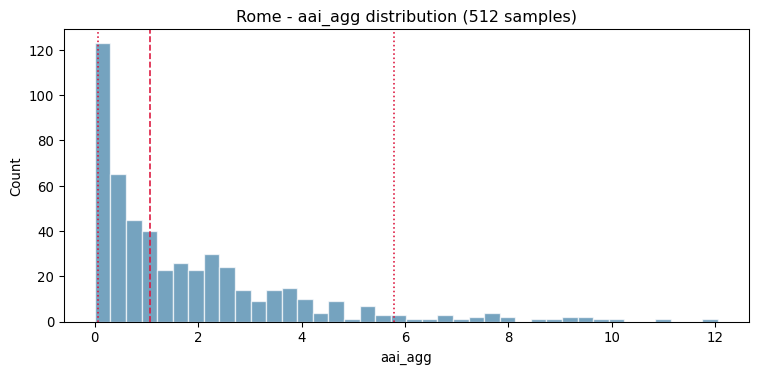

In [14]:
# Decode sampled parameters into human-readable labels
samples = unc.samples_df.copy()

def map_idx(series, options):
    return series.astype(int).map(lambda i: options[int(i)] if 0 <= int(i) < len(options) else None)

samples["year"] = map_idx(samples["YEAR_IDX"], YEARS)
samples["baseline_mode"] = map_idx(samples["BASELINE_MODE_IDX"], BASELINE_MODES)
samples["clim_scen"] = map_idx(samples["CLIM_SCEN_IDX"], CLIM_SCENS)
samples["clim_band"] = map_idx(samples["CLIM_BAND_IDX"], CLIM_BANDS)
samples["clim_source"] = map_idx(samples["CLIM_SOURCE_IDX"], CLIM_SOURCE_OPTIONS)
samples["gcm_model"] = map_idx(samples["GCM_MODEL_IDX"], GCM_OPTIONS)

samples["exp_ssp"] = map_idx(samples["EXP_SSP_IDX"], EXP_SSP_OPTIONS if EXP_SSP_OPTIONS else ["NA"])
samples["ac_ssp"] = map_idx(samples["AC_SSP_IDX"], AC_SSP_OPTIONS)

samples["wh_enabled"] = map_idx(samples["WH_ENABLED_IDX"], WH_ENABLED_OPTIONS)
samples["wh_case"] = map_idx(samples["WH_LUT_CASE_IDX"], WH_LUT_OPTIONS)
samples["cop_enabled"] = map_idx(samples["COP_ENABLED_IDX"], COP_ENABLED_OPTIONS)
samples["cop_case"] = map_idx(samples["COP_CASE_IDX"], COP_CASE_OPTIONS)

samples["if_family"] = map_idx(samples["IF_FAMILY_IDX"], IF_FAMILIES)
samples["t_ref_C"] = map_idx(samples["IF_TREF_IDX"], TREF_OPTIONS)
samples["ac_eff_scenario"] = map_idx(samples["AC_EFF_SCEN_IDX"], EFFICACY_SCENS)

samples["ews_interpretation"] = map_idx(samples["EWS_INTERP_IDX"], EWS_INTERP_OPTIONS)
samples["ews_cf_eff_level"] = map_idx(samples["EWS_CF_EFF_LEVEL_IDX"], LEVEL_OPTIONS)
samples["ews_eff_lt15_level"] = map_idx(samples["EWS_EFF_LT15_LEVEL_IDX"], LEVEL_OPTIONS)
samples["ews_eff_15_64_level"] = map_idx(samples["EWS_EFF_15_64_LEVEL_IDX"], LEVEL_OPTIONS)
samples["ews_eff_65p_level"] = map_idx(samples["EWS_EFF_65P_LEVEL_IDX"], LEVEL_OPTIONS)
samples["ews_overlap_level"] = map_idx(samples["EWS_OVERLAP_LEVEL_IDX"], LEVEL_OPTIONS)
samples["ews_disp_lt15_level"] = map_idx(samples["EWS_DISP_LT15_LEVEL_IDX"], LEVEL_OPTIONS)
samples["ews_disp_15_64_level"] = map_idx(samples["EWS_DISP_15_64_LEVEL_IDX"], LEVEL_OPTIONS)
samples["ews_disp_65p_level"] = map_idx(samples["EWS_DISP_65P_LEVEL_IDX"], LEVEL_OPTIONS)
samples["ews_ramp_years"] = map_idx(samples["EWS_RAMP_YEARS_IDX"], EWS_RAMP_OPTIONS)
samples["ews_target_days"] = map_idx(samples["EWS_TARGET_DAYS_IDX"], EWS_TARGET_DAYS_OPTIONS)
samples["ews_recalib_years"] = map_idx(samples["EWS_RECALIB_YEARS_IDX"], EWS_RECALIB_OPTIONS)
samples["ews_cost_model"] = map_idx(samples["EWS_COST_MODEL_IDX"], EWS_COST_MODEL_OPTIONS)

samples["tree_ramp_years"] = map_idx(samples["TREE_RAMP_YEARS_IDX"], TREE_RAMP_OPTIONS)
samples["tree_start_age"] = map_idx(samples["TREE_START_AGE_IDX"], TREE_START_AGE_OPTIONS)

samples["aai_agg"] = unc.aai_agg_unc_df["aai_agg"].values

print(f"aai_agg range: {samples['aai_agg'].min():.2f} to {samples['aai_agg'].max():.2f}")
display(samples[[
    "year", "clim_scen", "clim_band", "clim_source", "gcm_model", "baseline_mode", "exp_ssp", "if_family", "t_ref_C", "aai_agg"
]].head(20))

# Quick distribution plot
fig, ax = plt.subplots(figsize=(8, 4))
aai = samples["aai_agg"].values
ax.hist(aai, bins=40, alpha=0.7, color="#3A7CA5", edgecolor="white")
ax.axvline(np.percentile(aai, 5), color="crimson", ls=":", lw=1.2)
ax.axvline(np.percentile(aai, 50), color="crimson", ls="--", lw=1.2)
ax.axvline(np.percentile(aai, 95), color="crimson", ls=":", lw=1.2)
ax.set_title(f"{CITY} - aai_agg distribution ({len(aai)} samples)")
ax.set_xlabel("aai_agg")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(UNC_DIR / f"unc_distribution_aai_agg_{SLUG}.png", dpi=160)
plt.show()


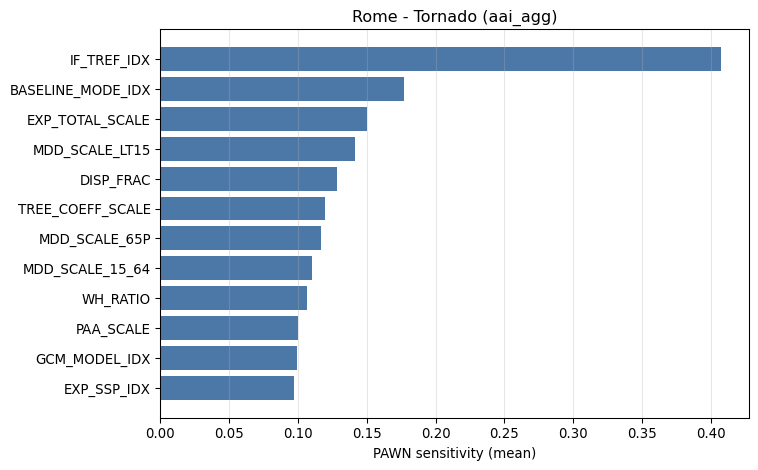

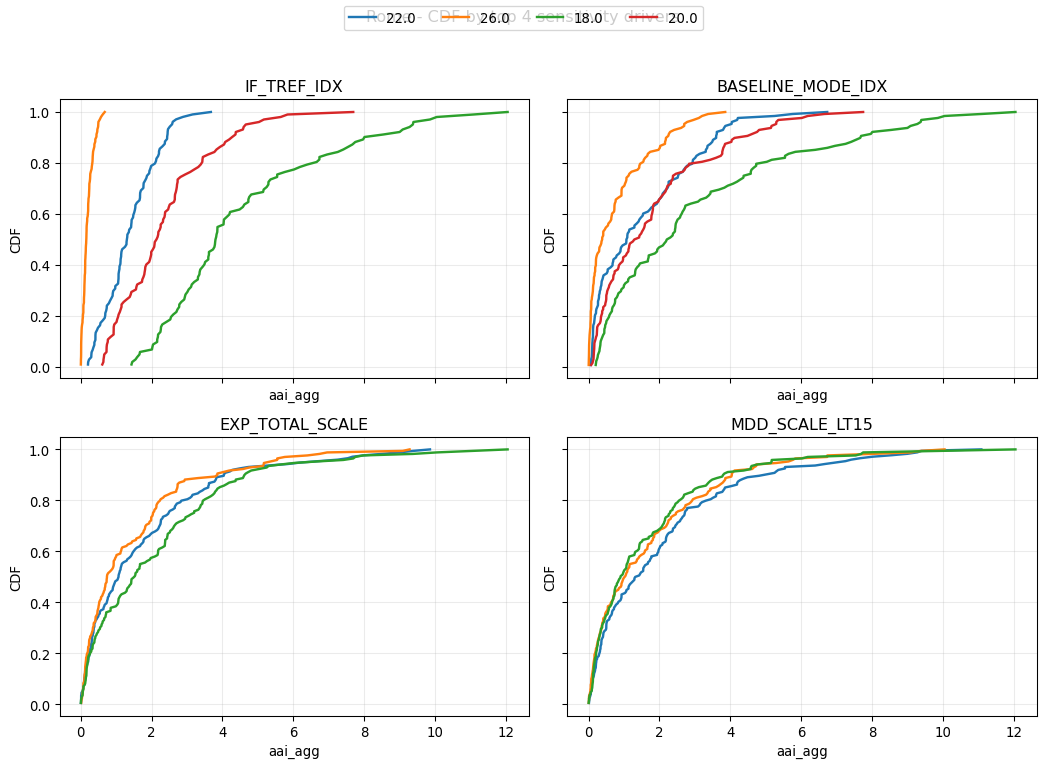

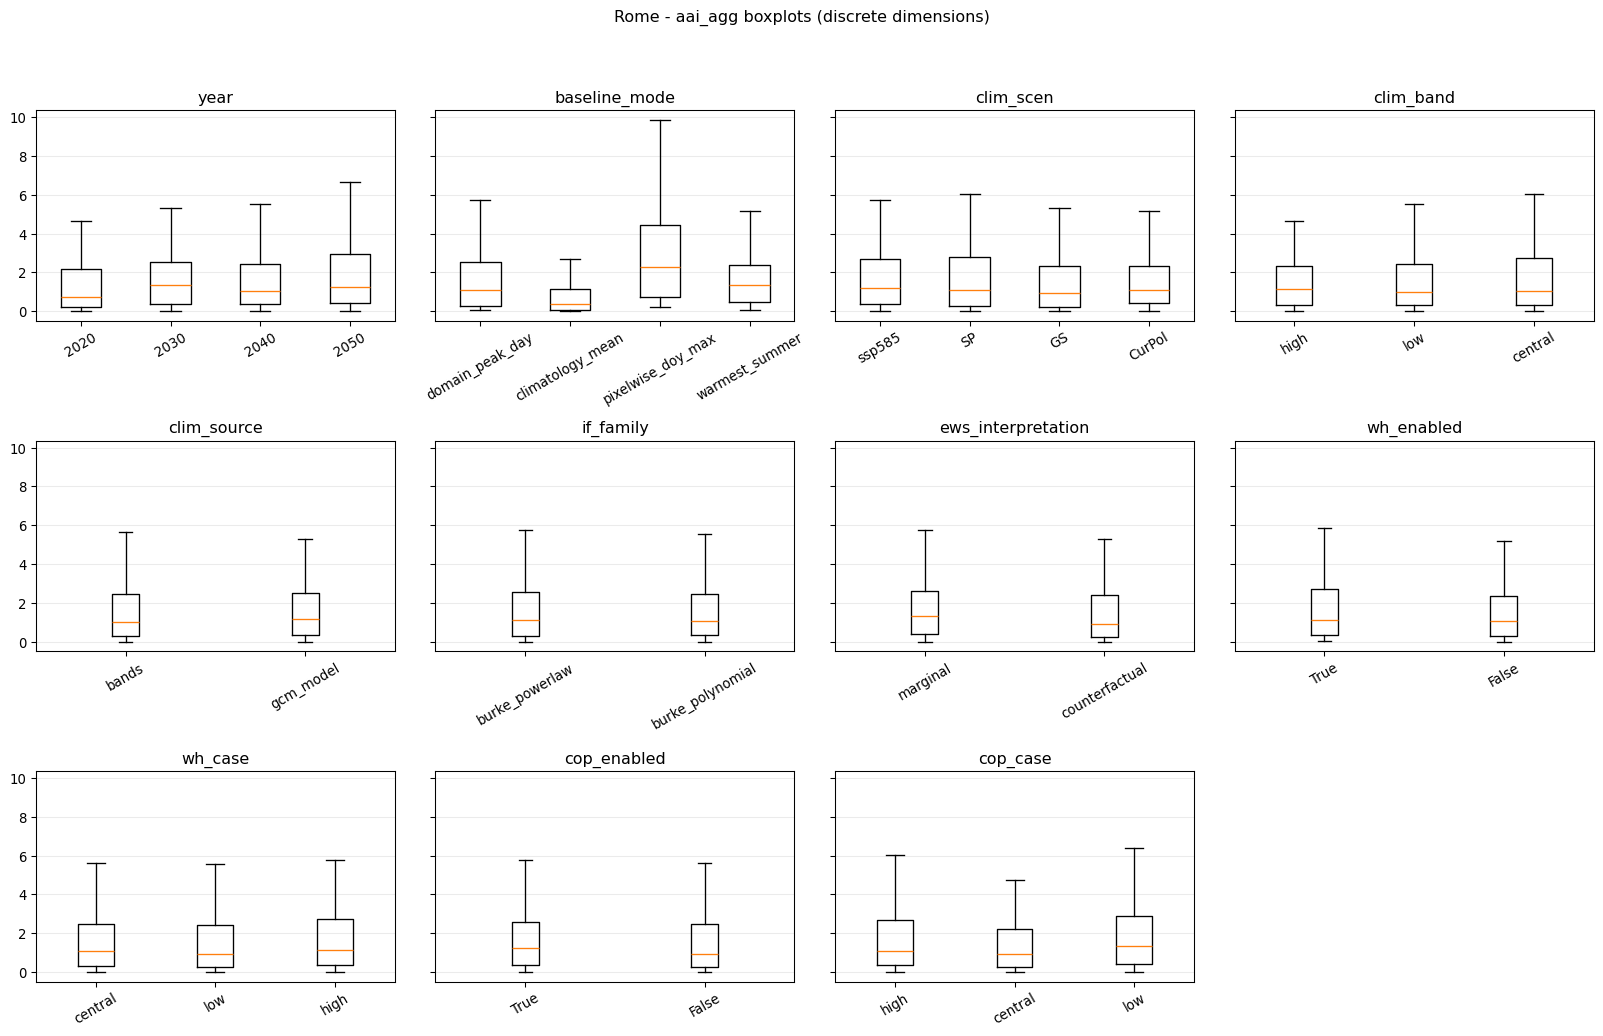

In [15]:
# Additional diagnostic figures (tornado, CDF, boxplots)
# to match earlier NB09 outputs while staying city-agnostic.

sens_df = sens.aai_agg_sens_df.copy()
if not isinstance(sens_df, pd.DataFrame):
    sens_df = pd.DataFrame(sens_df)
if "si" not in sens_df.columns:
    sens_df = sens_df.reset_index().rename(columns={"index": "si"})
if "si" not in sens_df.columns and len(sens_df.columns) > 0:
    sens_df = sens_df.rename(columns={sens_df.columns[0]: "si"})

if "aai_agg" not in sens_df.columns:
    cand = [c for c in sens_df.columns if str(c).lower().replace("_", "") in ("aaiagg", "aai")]
    if cand:
        sens_df = sens_df.rename(columns={cand[0]: "aai_agg"})

if "param" not in sens_df.columns:
    sens_df["param"] = "unknown"

mean_df = sens_df[sens_df["si"].astype(str).str.lower() == "mean"].copy()
if mean_df.empty:
    mean_df = sens_df.copy()

top = mean_df.sort_values("aai_agg", ascending=False).head(12)

# 1) Tornado plot
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = top.iloc[::-1]
ax.barh(plot_df["param"].astype(str), plot_df["aai_agg"].astype(float), color="#4C78A8")
ax.set_xlabel("PAWN sensitivity (mean)")
ax.set_title(f"{CITY} - Tornado (aai_agg)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(UNC_DIR / f"sens_tornado_aai_agg_{SLUG}.png", dpi=160)
plt.show()

# 2) CDF for top 4 drivers
param_to_col = {
    "YEAR_IDX": "year",
    "BASELINE_MODE_IDX": "baseline_mode",
    "CLIM_SCEN_IDX": "clim_scen",
    "CLIM_BAND_IDX": "clim_band",
    "CLIM_SOURCE_IDX": "clim_source",
    "GCM_MODEL_IDX": "gcm_model",
    "EXP_SSP_IDX": "exp_ssp",
    "AC_SSP_IDX": "ac_ssp",
    "WH_ENABLED_IDX": "wh_enabled",
    "WH_LUT_CASE_IDX": "wh_case",
    "COP_ENABLED_IDX": "cop_enabled",
    "COP_CASE_IDX": "cop_case",
    "IF_FAMILY_IDX": "if_family",
    "IF_TREF_IDX": "t_ref_C",
    "AC_EFF_SCEN_IDX": "ac_eff_scenario",
    "EWS_INTERP_IDX": "ews_interpretation",
    "EWS_CF_EFF_LEVEL_IDX": "ews_cf_eff_level",
    "EWS_EFF_LT15_LEVEL_IDX": "ews_eff_lt15_level",
    "EWS_EFF_15_64_LEVEL_IDX": "ews_eff_15_64_level",
    "EWS_EFF_65P_LEVEL_IDX": "ews_eff_65p_level",
    "EWS_OVERLAP_LEVEL_IDX": "ews_overlap_level",
    "EWS_DISP_LT15_LEVEL_IDX": "ews_disp_lt15_level",
    "EWS_DISP_15_64_LEVEL_IDX": "ews_disp_15_64_level",
    "EWS_DISP_65P_LEVEL_IDX": "ews_disp_65p_level",
    "EWS_RAMP_YEARS_IDX": "ews_ramp_years",
    "EWS_TARGET_DAYS_IDX": "ews_target_days",
    "EWS_RECALIB_YEARS_IDX": "ews_recalib_years",
    "EWS_COST_MODEL_IDX": "ews_cost_model",
    "TREE_RAMP_YEARS_IDX": "tree_ramp_years",
    "TREE_START_AGE_IDX": "tree_start_age",
}

def _ecdf(arr):
    x = np.sort(np.asarray(arr, dtype=float))
    if len(x) == 0:
        return x, x
    y = np.arange(1, len(x) + 1, dtype=float) / len(x)
    return x, y

top4 = top["param"].astype(str).head(4).tolist()
fig, axs = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axs = axs.ravel()

for k, param in enumerate(top4):
    ax = axs[k]
    col = param_to_col.get(param, param)
    if col not in samples.columns:
        ax.text(0.5, 0.5, f"{param}\n(not in samples)", ha="center", va="center")
        ax.set_axis_off()
        continue

    ser = samples[col]
    if pd.api.types.is_numeric_dtype(ser) and ser.nunique(dropna=True) > 6:
        q = ser.quantile([0.33, 0.67]).values
        bins = [-np.inf, q[0], q[1], np.inf]
        grp = pd.cut(ser, bins=bins, labels=["low", "mid", "high"])
    else:
        grp = ser.astype(str)

    tmp = pd.DataFrame({"grp": grp, "aai": samples["aai_agg"]}).dropna()
    levels = list(tmp["grp"].value_counts().head(4).index)

    for lvl in levels:
        arr = tmp.loc[tmp["grp"] == lvl, "aai"].values
        if len(arr) < 2:
            continue
        x, y = _ecdf(arr)
        ax.plot(x, y, lw=1.8, label=str(lvl))

    if not ax.lines:
        x_all, y_all = _ecdf(samples["aai_agg"].values)
        if len(x_all) > 0:
            ax.plot(x_all, y_all, lw=1.8, color="#555555", label="all")

    ax.set_title(param)
    ax.grid(alpha=0.25)

for ax in axs:
    ax.set_xlabel("aai_agg")
    ax.set_ylabel("CDF")

handles, labels = axs[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=min(4, len(labels)))
fig.suptitle(f"{CITY} - CDF by top 4 sensitivity drivers", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(UNC_DIR / f"sens_cdf_top4_{SLUG}.png", dpi=160)
plt.show()

# 3) Boxplots for key discrete dimensions
box_cols = [
    "year", "baseline_mode", "clim_scen", "clim_band", "clim_source",
    "if_family", "ews_interpretation", "wh_enabled", "wh_case", "cop_enabled", "cop_case",
]
box_cols = [c for c in box_cols if c in samples.columns]

n = len(box_cols)
ncols = 4
nrows = int(np.ceil(n / ncols)) if n else 1
fig, axs = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.6 * nrows), sharey=True)
axs = np.atleast_1d(axs).ravel()

for i, col in enumerate(box_cols):
    ax = axs[i]
    tmp = samples[[col, "aai_agg"]].dropna().copy()
    order = list(tmp[col].astype(str).value_counts().index)
    data = [tmp.loc[tmp[col].astype(str) == lvl, "aai_agg"].values for lvl in order]
    ax.boxplot(data, tick_labels=order, showfliers=False)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.25)

for j in range(i + 1, len(axs)):
    axs[j].set_axis_off()

fig.suptitle(f"{CITY} - aai_agg boxplots (discrete dimensions)", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(UNC_DIR / f"unc_boxplots_discrete_{SLUG}.png", dpi=160)
plt.show()


In [16]:
# Save outputs
samples.to_csv(UNC_DIR / f"unc_samples_{SLUG}.csv", index=False)
unc.aai_agg_unc_df.to_csv(UNC_DIR / f"unc_aai_agg_{SLUG}.csv", index=False)
unc.freq_curve_unc_df.to_csv(UNC_DIR / f"unc_freq_curve_{SLUG}.csv", index=False)

if hasattr(sens, "aai_agg_sens_df"):
    sens.aai_agg_sens_df.to_csv(UNC_DIR / f"sens_aai_agg_{SLUG}.csv")
if hasattr(sens, "freq_curve_sens_df"):
    sens.freq_curve_sens_df.to_csv(UNC_DIR / f"sens_freq_curve_{SLUG}.csv")

# Parameter-space metadata for reproducibility
meta = {
    "city": CITY,
    "slug": SLUG,
    "years": YEARS,
    "baseline_modes": BASELINE_MODES,
    "climate_scenarios": CLIM_SCENS,
    "climate_bands": CLIM_BANDS,
    "climate_source_options": CLIM_SOURCE_OPTIONS,
    "gcm_options": GCM_OPTIONS,
    "if_families": IF_FAMILIES,
    "t_ref_options": TREF_OPTIONS,
    "ac_ssp_options": AC_SSP_OPTIONS,
    "exp_ssp_options": EXP_SSP_OPTIONS,
    "ac_efficacy_scenarios": EFFICACY_SCENS,
    "ews_interp_options": EWS_INTERP_OPTIONS,
    "ews_level_options": LEVEL_OPTIONS,
    "ews_target_days_options": EWS_TARGET_DAYS_OPTIONS,
    "ews_recalib_options": EWS_RECALIB_OPTIONS,
    "wh_enabled_options": WH_ENABLED_OPTIONS,
    "cop_enabled_options": COP_ENABLED_OPTIONS,
    "tree_ramp_options": TREE_RAMP_OPTIONS,
    "tree_start_age_options": TREE_START_AGE_OPTIONS,
    "cop_case_options": COP_CASE_OPTIONS,
    "wasteheat_case_options": WH_LUT_OPTIONS,
    "notes": [
        "Hand-estimated IF families intentionally excluded.",
        "EWS cost model is sampled but does not affect mortality impact directly.",
        "Hazard structural modifiers are applied as daily city-mean deltas for tractability.",
        "EWS trigger/recalibration uncertainty is applied as a calibrated warning-days modifier over NB06 outputs.",
        "Bands and explicit GCM model-index are both sampled; source selection via CLIM_SOURCE_IDX.",
    ],
}
with open(UNC_DIR / f"uq_dimensions_{SLUG}.json", "w") as f:
    json.dump(meta, f, indent=2)

unc_h5 = unc.to_hdf5(UNC_DIR / f"unc_impact_{SLUG}_march2026")
sens_h5 = sens.to_hdf5(UNC_DIR / f"unc_impact_{SLUG}_march2026_with_sensitivity")

print("Saved uncertainty outputs in:", UNC_DIR)
print("unc hdf5:", unc_h5)
print("sens hdf5:", sens_h5)


Saved uncertainty outputs in: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/tables/uncertainty
unc hdf5: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/tables/uncertainty/unc_impact_rome_march2026.hdf5
sens hdf5: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/tables/uncertainty/unc_impact_rome_march2026_with_sensitivity.hdf5

/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/climada/engine/unsequa/unc_output.py:1162: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block1_values] [items->Index(['si', 'param', 'param2'], dtype='object')]

  store.put(var_name, var_val, format="fixed", complevel=9)